In [74]:
import tensorflow as tf

tf.__version__

'2.19.0'

In [75]:
url = "https://ai.stanford.edu/~amaas/data/sentiment/aclImdb_v1.tar.gz"
dataset = tf.keras.utils.get_file("aclImdb_v1", url,
                                    untar=True, cache_dir='.',
                                    cache_subdir='')


In [76]:
dataset

'./aclImdb_v1'

In [77]:
import os
from pathlib import Path

dataset_dir = Path(dataset)

os.listdir(dataset_dir)

['aclImdb']

In [78]:
list(dataset_dir.glob("*/*/"))

[PosixPath('aclImdb_v1/aclImdb/test'), PosixPath('aclImdb_v1/aclImdb/train')]

In [79]:
test_dir = list(dataset_dir.glob("*/*/"))[0]
train_dir = list(dataset_dir.glob("*/*/"))[1]

In [80]:
train_dir, test_dir

(PosixPath('aclImdb_v1/aclImdb/train'), PosixPath('aclImdb_v1/aclImdb/test'))

In [81]:
os.listdir(train_dir)

['urls_unsup.txt',
 'neg',
 'urls_pos.txt',
 'unsup',
 'urls_neg.txt',
 'pos',
 'unsupBow.feat',
 'labeledBow.feat']

In [82]:
import shutil

shutil.rmtree(train_dir/"unsup")

In [83]:
batch_size = 32
seed = 42

raw_train_ds = tf.keras.utils.text_dataset_from_directory(
    train_dir,
    batch_size=batch_size,
    validation_split=0.2,
    subset='training',
    seed=seed)

Found 25000 files belonging to 2 classes.
Using 20000 files for training.


In [84]:
len(raw_train_ds) * 32

20000

In [85]:
raw_train_ds.class_names

['neg', 'pos']

In [86]:
raw_val_ds = tf.keras.utils.text_dataset_from_directory(
    train_dir,
    batch_size=batch_size,
    validation_split=0.2,
    subset='validation',
    seed=seed)

Found 25000 files belonging to 2 classes.
Using 5000 files for validation.


In [87]:
raw_test_ds = tf.keras.utils.text_dataset_from_directory(
    test_dir,
    batch_size=batch_size,
    seed=seed
)

Found 25000 files belonging to 2 classes.


In [88]:
text = "hello how are You!"

tf.strings.lower(text)

<tf.Tensor: shape=(), dtype=string, numpy=b'hello how are you!'>

In [89]:
tf.strings.regex_replace(text, "!", "staticmethod")

<tf.Tensor: shape=(), dtype=string, numpy=b'hello how are Youstaticmethod'>

In [90]:
import re
import string

tf.strings.regex_replace(text, '[%s]' % re.escape(string.punctuation), "")

<tf.Tensor: shape=(), dtype=string, numpy=b'hello how are You'>

In [91]:
def custom_standardization(input_data):
  lowercase = tf.strings.lower(input_data)
  stripped_html = tf.strings.regex_replace(lowercase, '<br />', ' ')
  return tf.strings.regex_replace(stripped_html,
                                  '[%s]' % re.escape(string.punctuation),
                                  '')

In [92]:
max_features = 10000
sequence_length = 250

vectorize_layer = tf.keras.layers.TextVectorization(
    standardize=custom_standardization,
    max_tokens=max_features,
    output_mode='int',
    output_sequence_length=sequence_length)

In [93]:
vectorize_layer

<TextVectorization name=text_vectorization_1, built=False>

In [104]:
train_text = raw_train_ds.map(lambda x, y : x)

train_text

<_MapDataset element_spec=TensorSpec(shape=(None,), dtype=tf.string, name=None)>

In [106]:
vectorize_layer.adapt(train_text)

2025-05-13 09:28:37.400242: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [107]:
def vectorize_text(text, label):
  text = tf.expand_dims(text, -1)
  return vectorize_layer(text), label

In [109]:
# retrieve a batch (of 32 reviews and labels) from the dataset
text_batch, label_batch = next(iter(raw_train_ds))
first_review, first_label = text_batch[0], label_batch[0]
print("Review : ", first_review)
print("Label : ", raw_train_ds.class_names[first_label])
print("Vectorized review : ", vectorize_text(first_review, first_label))

Review :  tf.Tensor(b'"A young woman suffers from the delusion that she is a werewolf, based upon a family legend of an ancestor accused of and killed for allegedly being one. Due to her past treatment by men, she travels the countryside seducing and killing the men she meets. Falling in love with a kind man, her life appears to take a turn for the better when she is raped and her lover is killed by a band of thugs. Traumatized again by these latest events, the woman returns to her violent ways and seeks revenge on the thugs," according to the DVD sleeve\'s synopsis.<br /><br />Rino Di Silvestro\'s "La lupa mannara" begins with full frontal, writhing, moaning dance by shapely blonde Annik Borel, who (as Daniella Neseri) mistakenly believes she is a werewolf. The hottest part is when the camera catches background fire between her legs. The opening "flashback" reveals her hairy ancestor was (probably) a lycanthropic creature. Ms. Borel is, unfortunately, not a werewolf; she is merely a v

In [122]:
print("1287 ---> ",vectorize_layer.get_vocabulary()[1])
print('Vocabulary size: {}'.format(len(vectorize_layer.get_vocabulary())))


1287 --->  [UNK]
Vocabulary size: 10000


In [123]:
train_ds = raw_train_ds.map(vectorize_text)
val_ds = raw_val_ds.map(vectorize_text)
test_ds = raw_test_ds.map(vectorize_text)

In [127]:
next(iter(train_ds))[0][0]

<tf.Tensor: shape=(250,), dtype=int64, numpy=
array([2528,   13,    4, 2218,    5,   48,  227,   26,  488,   32,    2,
         83,   86, 1007, 6768, 6996,    5,    2,    1,    3,    9,   13,
        986,  581,   20,  681,  708,    1,   84,    5,    2,  598,    8,
          2, 2174, 1033,   32,    2,  333,   86, 1007, 6768, 6996,   60,
        606,   16, 3114,    3, 5437,  104,  149,  589,   71, 3780,   25,
          8,    2, 4959,    2, 6768, 6887, 1587, 1007,    3,    1,   25,
        986, 1118,  297,  243,   91,  443,   20, 6768, 2630,  129, 1429,
          1,    1,    2,   61,   28,    5,    2, 1539,  653, 2630,   21,
          6,   25,   74,  814, 2353,   37,    2, 6996,  139,  148,   26,
        555,   57,  803,  189,   47,   76,   26,   50,    6,  203,    8,
          2,  781,  701,   47,    7,  101,   30,   39, 3697,  115,    3,
          1,    1,    2,  350,    1,  729, 2744,    3,  282, 1116,   43,
          1,    1, 4055,    6,   39,  104,    1,    1,    2,    1,    3,
     

In [132]:
embedding_dim = 16
from tensorflow.keras import layers, losses
model = tf.keras.Sequential([
  layers.Embedding(max_features, embedding_dim),
  layers.Dropout(0.2),
  layers.GlobalAveragePooling1D(),
  layers.Dropout(0.2),
  layers.Dense(1, activation='sigmoid')])

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_1      │ ?                      │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [133]:
model.compile(loss=losses.BinaryCrossentropy(),
              optimizer='adam',
              metrics=[tf.metrics.BinaryAccuracy(threshold=0.5)])

In [134]:
epochs = 10
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=epochs)

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - binary_accuracy: 0.5794 - loss: 0.6823 - val_binary_accuracy: 0.7340 - val_loss: 0.6131
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - binary_accuracy: 0.7546 - loss: 0.5800 - val_binary_accuracy: 0.8136 - val_loss: 0.4950
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - binary_accuracy: 0.8174 - loss: 0.4680 - val_binary_accuracy: 0.8394 - val_loss: 0.4217
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - binary_accuracy: 0.8493 - loss: 0.3957 - val_binary_accuracy: 0.8494 - val_loss: 0.3810
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - binary_accuracy: 0.8649 - loss: 0.3520 - val_binary_accuracy: 0.8574 - val_loss: 0.3535
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - binary_accuracy: 0.8789 - loss: 0.3181 - val_binary_accuracy: 0.8690 - val_loss: 0.3312
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - binary_accuracy: 0.8870 - loss: 0.2948 - val_binary_accuracy: 0.8474 - val_loss: 0.3413
Epoch 

In [135]:
loss, accuracy = model.evaluate(test_ds)

print("Loss: ", loss)
print("Accuracy: ", accuracy)

782/782 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - binary_accuracy: 0.8669 - loss: 0.3168
Loss:  0.31422021985054016
Accuracy:  0.8716800212860107


In [136]:
history_dict = history.history
history_dict.keys()

dict_keys(['binary_accuracy', 'loss', 'val_binary_accuracy', 'val_loss'])

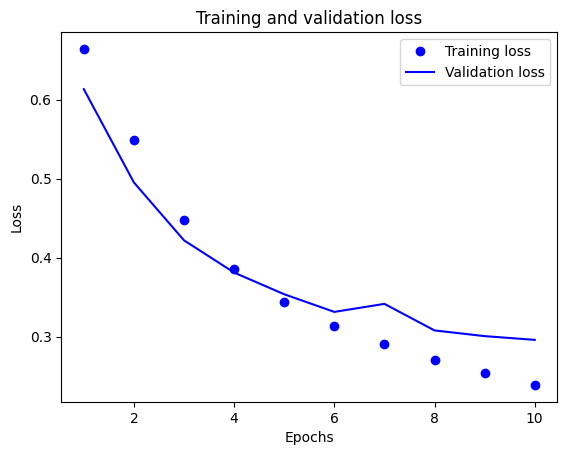

In [139]:
import matplotlib.pyplot as plt
acc = history_dict['binary_accuracy']
val_acc = history_dict['val_binary_accuracy']
loss = history_dict['loss']
val_loss = history_dict['val_loss']

epochs = range(1, len(acc) + 1)

# "bo" is for "blue dot"
plt.plot(epochs, loss, 'bo', label='Training loss')
# b is for "solid blue line"
plt.plot(epochs, val_loss, 'b', label='Validation loss')
plt.title('Training and validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()